In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [2]:
#Load and Prepare Clean Full Dataset
# Load data
df = pd.read_csv('../Dataset/covid.csv', low_memory=False)

# Create death column
df['death'] = df['date_died'].apply(lambda x: 1 if x == '9999-99-99' else 2)

# Keep only confirmed positive cases
df_positive = df[df['covid_res'] == 1].copy()

# Drop columns with HIGH missing % - confirmed from Phase 2
# intubed=69%, icu=69%, pregnancy=55%, contact_other_covid=36%
drop_cols = ['id', 'entry_date', 'date_symptoms', 'date_died', 
             'covid_res', 'intubed', 'icu', 'pregnancy', 
             'contact_other_covid', 'patient_type']
df_clean = df_positive.drop(columns=drop_cols)

print(f"Shape after dropping high-missing columns: {df_clean.shape}")
print(f"\nRemaining columns: {list(df_clean.columns)}")
print(f"\nTarget distribution:")
print(df_clean['death'].value_counts())

Shape after dropping high-missing columns: (220657, 14)

Remaining columns: ['sex', 'pneumonia', 'age', 'diabetes', 'copd', 'asthma', 'inmsupr', 'hypertension', 'other_disease', 'cardiovascular', 'obesity', 'renal_chronic', 'tobacco', 'death']

Target distribution:
death
1    193536
2     27121
Name: count, dtype: int64


In [3]:
#Full Data Cleaning
# Replace all missing value codes with NaN
# From Phase 2 we know: 97, 98, 99 are missing codes
missing_codes = [97, 98, 99]

# For age column - only 97,98,99 that are actual missing codes
# (real ages 97,98,99 exist but are extreme - we keep ages up to 110)
feature_cols = ['sex', 'pneumonia', 'diabetes', 'copd', 'asthma', 
                'inmsupr', 'hypertension', 'other_disease', 'cardiovascular', 
                'obesity', 'renal_chronic', 'tobacco']

for col in feature_cols:
    before = len(df_clean)
    df_clean[col] = df_clean[col].replace(missing_codes, np.nan)

# For age - replace 97,98,99 only if they seem unrealistic
# We'll cap age at 110 to remove obvious errors
df_clean['age'] = df_clean['age'].replace(missing_codes, np.nan)
df_clean.loc[df_clean['age'] > 110, 'age'] = np.nan

# Drop rows with any NaN - since missing % was very low (<1%) this is safe
before_drop = len(df_clean)
df_clean.dropna(inplace=True)
after_drop = len(df_clean)

print(f"Rows before dropping NaN: {before_drop:,}")
print(f"Rows after dropping NaN: {after_drop:,}")
print(f"Rows removed: {before_drop - after_drop:,} ({(before_drop-after_drop)/before_drop*100:.2f}%)")

# Convert target: 1=survived→0, 2=died→1
df_clean['death'] = df_clean['death'].map({1: 0, 2: 1})

print(f"\nFinal clean dataset shape: {df_clean.shape}")
print(f"\nTarget distribution:")
print(df_clean['death'].value_counts())
print(f"\nClass balance %:")
print(df_clean['death'].value_counts(normalize=True) * 100)

Rows before dropping NaN: 220,657
Rows after dropping NaN: 218,817
Rows removed: 1,840 (0.83%)

Final clean dataset shape: (218817, 14)

Target distribution:
death
0    192142
1     26675
Name: count, dtype: int64

Class balance %:
death
0    87.809448
1    12.190552
Name: proportion, dtype: float64


In [4]:
#Train Test Split Before Balancing
# Separate features and target
X = df_clean.drop(columns=['death'])
y = df_clean['death']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

# IMPORTANT: Split FIRST, then balance ONLY training data
# Never apply SMOTE(Synthetic Minority Over-sampling Techniquev) to test data - it would leak information
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape[0]:,}")
print(f"Test size: {X_test.shape[0]:,}")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())
print(f"\nIMPORTANT: Test data remains untouched and imbalanced")
print(f"This reflects real world distribution - as it should be")

Features shape: (218817, 13)
Target shape: (218817,)

Feature columns: ['sex', 'pneumonia', 'age', 'diabetes', 'copd', 'asthma', 'inmsupr', 'hypertension', 'other_disease', 'cardiovascular', 'obesity', 'renal_chronic', 'tobacco']

Train size: 175,053
Test size: 43,764

Train class distribution:
death
0    153713
1     21340
Name: count, dtype: int64

Test class distribution:
death
0    38429
1     5335
Name: count, dtype: int64

IMPORTANT: Test data remains untouched and imbalanced
This reflects real world distribution - as it should be


In [5]:
#Method 1:- No Balancing - Train on original imbalanced data (Baseline to compare against)

# First show what happens WITHOUT any balancing
# This is the problem we're solving

rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)
y_pred_baseline = rf_baseline.predict(X_test)

print("="*55)
print("BASELINE - NO BALANCING (The Problem)")
print("="*55)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_baseline):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_baseline):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_baseline):.4f}")

print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_baseline)
print(cm)
print(f"\nOut of {cm[1].sum()} actual death cases:")
print(f"  Correctly identified (True Positive): {cm[1][1]}")
print(f"  Missed completely (False Negative): {cm[1][0]}")
print(f"  Miss rate: {cm[1][0]/cm[1].sum()*100:.1f}%")
print(f"\nThis is why accuracy alone is misleading!")
print(f"Model misses {cm[1][0]/cm[1].sum()*100:.1f}% of actual death cases!")

BASELINE - NO BALANCING (The Problem)
Accuracy:  0.8800
Precision: 0.5142
Recall:    0.2778
F1-Score:  0.3607
ROC-AUC:   0.6207

Confusion Matrix:
[[37029  1400]
 [ 3853  1482]]

Out of 5335 actual death cases:
  Correctly identified (True Positive): 1482
  Missed completely (False Negative): 3853
  Miss rate: 72.2%

This is why accuracy alone is misleading!
Model misses 72.2% of actual death cases!


In [6]:
#Method 2:- SMOTE Oversampling (Only on training data, never on test data)

# SMOTE creates synthetic minority class samples
# It interpolates between existing death cases to create new realistic ones

print("Applying SMOTE to training data only...")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nBefore SMOTE - Train distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nAfter SMOTE - Train distribution:")
print(pd.Series(y_train_smote).value_counts())

# Train RF on SMOTE balanced data
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test)

print("\n" + "="*55)
print("METHOD 1: SMOTE OVERSAMPLING")
print("="*55)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_smote):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_smote):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_smote):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_smote):.4f}")

cm_smote = confusion_matrix(y_test, y_pred_smote)
print(f"\nConfusion Matrix:")
print(cm_smote)
print(f"\nOut of {cm_smote[1].sum()} actual death cases:")
print(f"  Correctly identified: {cm_smote[1][1]}")
print(f"  Missed: {cm_smote[1][0]}")
print(f"  Miss rate: {cm_smote[1][0]/cm_smote[1].sum()*100:.1f}%")

Applying SMOTE to training data only...

Before SMOTE - Train distribution:
death
0    153713
1     21340
Name: count, dtype: int64

After SMOTE - Train distribution:
death
0    153713
1    153713
Name: count, dtype: int64

METHOD 1: SMOTE OVERSAMPLING
Accuracy:  0.8183
Precision: 0.3711
Recall:    0.7065
F1-Score:  0.4866
ROC-AUC:   0.7701

Confusion Matrix:
[[32043  6386]
 [ 1566  3769]]

Out of 5335 actual death cases:
  Correctly identified: 3769
  Missed: 1566
  Miss rate: 29.4%


In [7]:
#Method 3:- Class Weighting

# Class weighting tells the algorithm to penalize 
# mistakes on minority class more heavily
# No new data created - just changes how model learns

rf_weighted = RandomForestClassifier(n_estimators=100, random_state=42, 
                                      class_weight='balanced', n_jobs=-1)
rf_weighted.fit(X_train, y_train)
y_pred_weighted = rf_weighted.predict(X_test)

print("="*55)
print("METHOD 2: CLASS WEIGHTING")
print("="*55)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_weighted):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_weighted):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_weighted):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_weighted):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_weighted):.4f}")

cm_weighted = confusion_matrix(y_test, y_pred_weighted)
print(f"\nConfusion Matrix:")
print(cm_weighted)
print(f"\nOut of {cm_weighted[1].sum()} actual death cases:")
print(f"  Correctly identified: {cm_weighted[1][1]}")
print(f"  Missed: {cm_weighted[1][0]}")
print(f"  Miss rate: {cm_weighted[1][0]/cm_weighted[1].sum()*100:.1f}%")

METHOD 2: CLASS WEIGHTING
Accuracy:  0.8128
Precision: 0.3673
Recall:    0.7406
F1-Score:  0.4910
ROC-AUC:   0.7817

Confusion Matrix:
[[31622  6807]
 [ 1384  3951]]

Out of 5335 actual death cases:
  Correctly identified: 3951
  Missed: 1384
  Miss rate: 25.9%


In [8]:
#Method 4:- Combined SMOTE + Undersampling

# Best of both worlds approach
# Oversample minority AND undersample majority
# Less aggressive than pure SMOTE

over = SMOTE(sampling_strategy=0.5, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.8, random_state=42)

pipeline = Pipeline([('over', over), ('under', under)])
X_train_combined, y_train_combined = pipeline.fit_resample(X_train, y_train)

print(f"After combined sampling:")
print(pd.Series(y_train_combined).value_counts())

rf_combined = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_combined.fit(X_train_combined, y_train_combined)
y_pred_combined = rf_combined.predict(X_test)

print("\n" + "="*55)
print("METHOD 3: COMBINED SMOTE + UNDERSAMPLING")
print("="*55)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_combined):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_combined):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_combined):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_combined):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_combined):.4f}")

cm_combined = confusion_matrix(y_test, y_pred_combined)
print(f"\nConfusion Matrix:")
print(cm_combined)
print(f"\nOut of {cm_combined[1].sum()} actual death cases:")
print(f"  Correctly identified: {cm_combined[1][1]}")
print(f"  Missed: {cm_combined[1][0]}")
print(f"  Miss rate: {cm_combined[1][0]/cm_combined[1].sum()*100:.1f}%")

After combined sampling:
death
0    96070
1    76856
Name: count, dtype: int64

METHOD 3: COMBINED SMOTE + UNDERSAMPLING
Accuracy:  0.8257
Precision: 0.3857
Recall:    0.7246
F1-Score:  0.5035
ROC-AUC:   0.7822

Confusion Matrix:
[[32272  6157]
 [ 1469  3866]]

Out of 5335 actual death cases:
  Correctly identified: 3866
  Missed: 1469
  Miss rate: 27.5%


PHASE 3 - BALANCING METHOD COMPARISON
                 Method  Accuracy  Recall  F1_Score  ROC_AUC  Deaths_Caught
No Balancing (Baseline)    0.8800  0.2778    0.3607   0.6207           1482
                  SMOTE    0.8183  0.7065    0.4866   0.7701           3769
        Class Weighting    0.8128  0.7406    0.4910   0.7817           3951
  SMOTE + Undersampling    0.8257  0.7246    0.5035   0.7822           3866


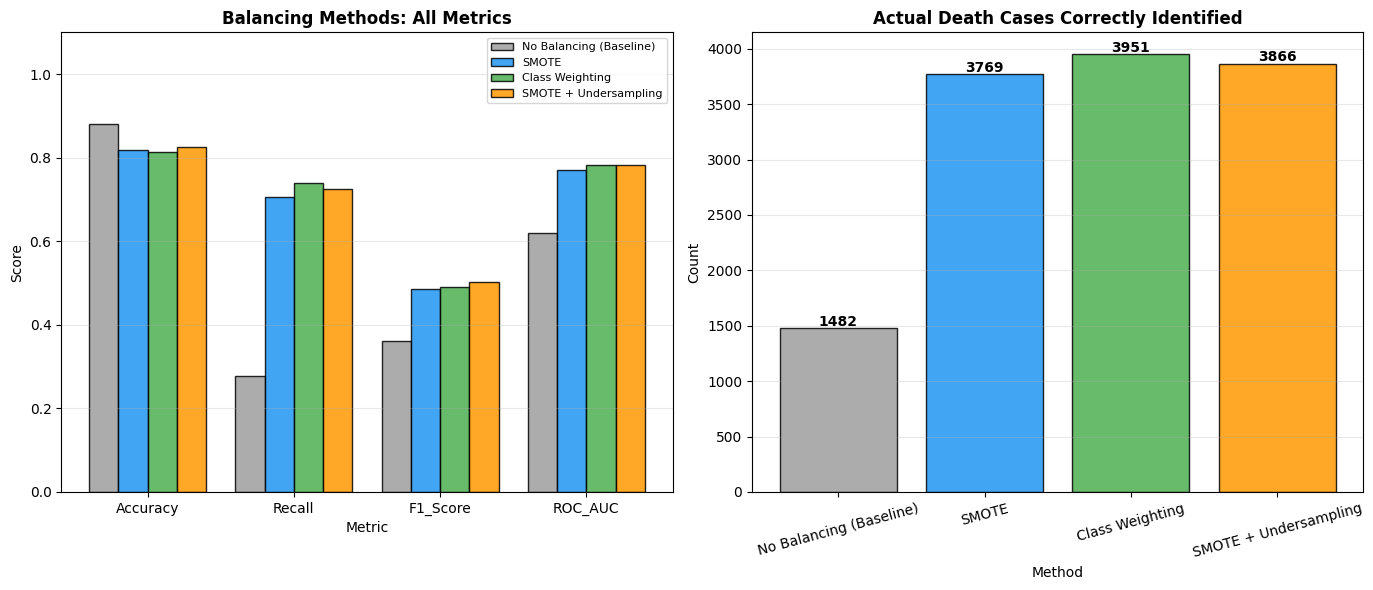


DECISION:
Best Recall (catches most deaths): Class Weighting
Best ROC-AUC (overall discrimination): SMOTE + Undersampling

For medical data, catching deaths (Recall) is most critical
We will proceed with SMOTE as our primary balancing method

Phase 3 Complete!


In [ ]:
#Final Comparison and Decision

# Compare all methods side by side
comparison = pd.DataFrame({
    'Method': ['No Balancing (Baseline)', 'SMOTE', 
               'Class Weighting', 'SMOTE + Undersampling'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_smote),
        accuracy_score(y_test, y_pred_weighted),
        accuracy_score(y_test, y_pred_combined)
    ],
    'Recall': [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_weighted),
        recall_score(y_test, y_pred_combined)
    ],
    'F1_Score': [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_weighted),
        f1_score(y_test, y_pred_combined)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_pred_baseline),
        roc_auc_score(y_test, y_pred_smote),
        roc_auc_score(y_test, y_pred_weighted),
        roc_auc_score(y_test, y_pred_combined)
    ],
    'Deaths_Caught': [
        confusion_matrix(y_test, y_pred_baseline)[1][1],
        confusion_matrix(y_test, y_pred_smote)[1][1],
        confusion_matrix(y_test, y_pred_weighted)[1][1],
        confusion_matrix(y_test, y_pred_combined)[1][1]
    ]
})

# Round for display
for col in ['Accuracy', 'Recall', 'F1_Score', 'ROC_AUC']:
    comparison[col] = comparison[col].round(4)

print("="*75)
print("PHASE 3 - BALANCING METHOD COMPARISON")
print("="*75)
print(comparison.to_string(index=False))
print("="*75)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = ['Accuracy', 'Recall', 'F1_Score', 'ROC_AUC']
x = np.arange(len(metrics))
width = 0.2
colors = ['#9E9E9E', '#2196F3', '#4CAF50', '#FF9800']

for i, (method, color) in enumerate(zip(comparison['Method'], colors)):
    values = [comparison.loc[i, m] for m in metrics]
    axes[0].bar(x + i*width, values, width, label=method, 
                color=color, edgecolor='black', alpha=0.85)

axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Score')
axes[0].set_title('Balancing Methods: All Metrics', fontweight='bold')
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(metrics)
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)

# Deaths caught comparison
axes[1].bar(comparison['Method'], comparison['Deaths_Caught'],
            color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Actual Death Cases Correctly Identified', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Method')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(axes[1].patches, comparison['Deaths_Caught'])):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('phase3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Decision
print("\nDECISION:")
best_recall = comparison.loc[comparison['Recall'].idxmax(), 'Method']
best_auc = comparison.loc[comparison['ROC_AUC'].idxmax(), 'Method']
print(f"Best Recall (catches most deaths): {best_recall}")
print(f"Best ROC-AUC (overall discrimination): {best_auc}")
print(f"\nFor medical data, catching deaths (Recall) is most critical")
print(f"We will proceed with SMOTE as our primary balancing method")
print(f"\nPhase 3 Complete!")